In [9]:
# === 基础数据处理与可视化 ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === 统计检验与建模 ===
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests
from scipy.stats import chi2_contingency, norm

# === 机器学习 ===
from sklearn.linear_model import LogisticRegression

In [10]:
# 设置中文字体（以黑体为例，Windows 可用 SimHei，macOS 可用 'Arial Unicode MS'）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 或 ['Microsoft YaHei']、['WenQuanYi Zen Hei']
plt.rcParams['axes.unicode_minus'] = False   # 解决负号显示异常

In [11]:
#读取数据。发现有索引列，直接引用
df = pd.read_csv('D:/myproject/data/marketing_AB.csv', index_col=0)

In [12]:
#看数据具体情况
print("\n前十列数据情况:\n",df.head(10))

# 看形状和类型
print("数据集形状:",df.shape)
print("\n列数据类型:\n",df.dtypes)

# 计算每列缺失比例，并按严重程度从高到低排列
print("\n缺失值统计:\n",df.isnull().mean().sort_values(ascending=False))
#检查重复数据
print("\n重复行数:\n", df.duplicated().sum())

# 显示全列统计摘要，包括文本列的唯一值情况
print("\n全列统计摘要:\n",df.describe(include='all'))


前十列数据情况:
    user id test group  converted  total ads most ads day  most ads hour
0  1069124         ad      False        130       Monday             20
1  1119715         ad      False         93      Tuesday             22
2  1144181         ad      False         21      Tuesday             18
3  1435133         ad      False        355      Tuesday             10
4  1015700         ad      False        276       Friday             14
5  1137664         ad      False        734     Saturday             10
6  1116205         ad      False        264    Wednesday             13
7  1496843         ad      False         17       Sunday             18
8  1448851         ad      False         21      Tuesday             19
9  1446284         ad      False        142       Monday             14
数据集形状: (588101, 6)

列数据类型:
 user id           int64
test group       object
converted          bool
total ads         int64
most ads day     object
most ads hour     int64
dtype: object

缺失值统计:
 us

In [13]:
# ==================== 实验功效验证 ====================
alpha = 0.05           # 显著性水平
power = 0.80           # 功效
mde = 0.01             # 最小可检测效应（1个百分点）

# 用真实的对照组转化率作为基线（实验后验证，不再假设）
baseline_cr = df[df['test group'] == 'psa']['converted'].mean()

# 单尾检验对应的 Z 值
z_alpha = norm.ppf(1 - alpha)   # 约 1.645
z_beta  = norm.ppf(power)       # 约 0.842

# 预期实验组转化率（对照组 + 我们想检测的最小提升）
p1 = baseline_cr + mde
p2 = baseline_cr

# 两组合并比例（用于零假设下的方差估计）
p_bar = (p1 + p2) / 2

# 精确样本量公式
numerator = (z_alpha * np.sqrt(p1*(1-p1) + p2*(1-p2)) + 
             z_beta  * np.sqrt(2 * p_bar * (1 - p_bar)))**2
denominator = (p1 - p2)**2

n_per_group = numerator / denominator

# 实际各组样本量
n_ad = df[df['test group'] == 'ad'].shape[0]
n_psa = df[df['test group'] == 'psa'].shape[0]

print(f"对照组实际转化率: {baseline_cr:.4%}")
print(f"最小可检测效应 (MDE): {mde:.1%}")
print(f"每组所需最小样本量: {int(np.ceil(n_per_group))}")
print(f"实际广告组样本量: {n_ad:,}")
print(f"实际对照组样本量: {n_psa:,}")
print(f"结论: 实际样本量远超最低要求，统计功效充足。")

对照组实际转化率: 1.7854%
最小可检测效应 (MDE): 1.0%
每组所需最小样本量: 2760
实际广告组样本量: 564,577
实际对照组样本量: 23,524
结论: 实际样本量远超最低要求，统计功效充足。


 主效应分析

In [14]:
# ==================== 主假设检验：广告是否显著提升了转化率？ ====================

# 1. 数据准备：将布尔值转化为 0 和 1 的数值
#    原理：True/False 变成 1/0，求均值就得到了转化率
df['conversion'] = df['converted'].astype(int)

# 2. 分别提取实验组和对照组的转化数据
ad_conv = df[df['test group'] == 'ad']['conversion']      # 实验组，所有看到商业广告的用户
psa_conv = df[df['test group'] == 'psa']['conversion']    # 对照组，所有看到公益广告的用户

# 3. 计算并对比两组转化率
cr_ad = ad_conv.mean()    # 实验组转化率 (mean of 0/1 = proportion of 1's)
cr_psa = psa_conv.mean()  # 对照组转化率
lift_abs = cr_ad - cr_psa              # 绝对提升量
lift_rel = (lift_abs / cr_psa) * 100   # 相对提升百分比

print(f"广告组转化率 (CR_ad) : {cr_ad:.4%}")
print(f"对照组转化率 (CR_psa): {cr_psa:.4%}")
print(f"绝对提升 (Absolute Lift): {lift_abs:.4%} ({lift_abs*100:.2f} 个百分点)")
print(f"相对提升 (Relative Lift): {lift_rel:.2f}%\n")

# 4. 主假设检验：两样本比例 Z 检验 (单尾)
#    H₀: CR_ad = CR_psa  (广告无效)
#    H₁: CR_ad > CR_psa  (广告有效)
#    alternative='larger' 表示单尾检验

count_ad = ad_conv.sum()   # 实验组购买人数
n_ad = len(ad_conv)        # 实验组总人数
count_psa = psa_conv.sum() # 对照组购买人数
n_psa = len(psa_conv)      # 对照组总人数

z_stat, p_value = proportions_ztest(
    count=[count_ad, count_psa],
    nobs=[n_ad, n_psa],
    alternative='larger'   # 因为我们的备择假设是 ad > psa
)

print(f"Z 统计量 (Z-statistic): {z_stat:.4f}")
print(f"P 值 (P-value): {p_value:.6f}\n")

alpha = 0.05  # 我们设定的显著性水平
if p_value < alpha:
    print("✅ 结论：拒绝零假设 H₀。")
    print("   在 95% 置信水平下，商业广告组的转化率显著高于公益广告组。")
    print("   这意味着广告对提升购买转化有真实效果，并非随机波动。")
else:
    print("❌ 结论：无法拒绝零假设 H₀。")
    print("   没有足够证据表明商业广告能提升转化率。")

# 5. Bootstrap 稳健性检验 (补充验证)
#    目的：不依赖正态假设，用重抽样方法直接估计提升量的 95% 置信区间
print("\n--- Bootstrap 稳健性检验 ---")
np.random.seed(42)  # 设置随机种子，保证结果可复现

def bootstrap_diff(data1, data2, n_iter=10000):
    """
    用 Bootstrap 方法计算两组均值差的 95% 置信区间
    data1: 实验组数据 (0/1数组)
    data2: 对照组数据 (0/1数组)
    n_iter: 重抽样次数
    """
    diffs = []
    n1, n2 = len(data1), len(data2)
    for _ in range(n_iter):
        # 有放回地随机抽样，样本量与原始组相同
        sample1 = np.random.choice(data1, size=n1, replace=True)
        sample2 = np.random.choice(data2, size=n2, replace=True)
        diff = sample1.mean() - sample2.mean()
        diffs.append(diff)
    # 取 2.5% 和 97.5% 分位数作为 95% 置信区间
    return np.percentile(diffs, [2.5, 97.5])

boot_ci = bootstrap_diff(ad_conv.values, psa_conv.values)
print(f"Bootstrap 95% 置信区间 (提升量): [{boot_ci[0]:.4%}, {boot_ci[1]:.4%}]")
print("(如果该区间不包含 0，则与 Z 检验结论一致，结果稳健。)")

广告组转化率 (CR_ad) : 2.5547%
对照组转化率 (CR_psa): 1.7854%
绝对提升 (Absolute Lift): 0.7692% (0.77 个百分点)
相对提升 (Relative Lift): 43.09%

Z 统计量 (Z-statistic): 7.3701
P 值 (P-value): 0.000000

✅ 结论：拒绝零假设 H₀。
   在 95% 置信水平下，商业广告组的转化率显著高于公益广告组。
   这意味着广告对提升购买转化有真实效果，并非随机波动。

--- Bootstrap 稳健性检验 ---
Bootstrap 95% 置信区间 (提升量): [0.5927%, 0.9409%]
(如果该区间不包含 0，则与 Z 检验结论一致，结果稳健。)


每日转化率分析

In [15]:
# ==================== 第 1 小步：每日卡方独立性检验 ====================

days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_results = []

for day in days:
    # 筛选该天的数据
    day_data = df[df['most ads day'] == day]
    
    # 构建 2×2 列联表（广告类型 × 是否购买）
    contingency = pd.crosstab(
        day_data['test group'], 
        day_data['converted'],
        margins=False
    )
    
    # 卡方独立性检验
    chi2, p_val, dof, expected = chi2_contingency(contingency)
    
    # 计算该天两组的转化率
    cr_ad_day = day_data[day_data['test group'] == 'ad']['converted'].mean()
    cr_psa_day = day_data[day_data['test group'] == 'psa']['converted'].mean()
    lift_day = cr_ad_day - cr_psa_day
    
    daily_results.append({
        '星期': day,
        '广告组转化率': cr_ad_day,
        '对照组转化率': cr_psa_day,
        '绝对提升': lift_day,
        '卡方统计量': chi2,
        'P值': p_val
    })

daily_df = pd.DataFrame(daily_results)
print("每日卡方独立性检验结果（未校正）：")
display(daily_df.round(4))

每日卡方独立性检验结果（未校正）：


,星期,广告组转化率,对照组转化率,绝对提升,卡方统计量,P值
0,Monday,0.0332,0.0226,0.0107,11.7525,0.0006
1,Tuesday,0.0304,0.0144,0.0160,24.1692,0.0000
2,Wednesday,0.0254,0.0158,0.0096,12.2543,0.0005
3,Thursday,0.0216,0.0202,0.0014,0.2854,0.5932
4,Friday,0.0225,0.0163,0.0062,6.0952,0.0136
5,Saturday,0.0213,0.0140,0.0073,6.8026,0.0091
6,Sunday,0.0246,0.0206,0.0040,1.8361,0.1754


In [16]:
# ==================== 第 2 小步：FDR-BH 多重检验校正 ====================

p_values_uncorrected = daily_df['P值'].values
rejected, p_values_corrected, _, _ = multipletests(
    p_values_uncorrected, 
    alpha=0.05, 
    method='fdr_bh'           # Benjamini-Hochberg 方法
)

daily_df['校正后P值'] = p_values_corrected
daily_df['是否显著（校正后）'] = rejected

print("\nFDR-BH 校正后结果：")
display(daily_df[['星期', '绝对提升', 'P值', '校正后P值', '是否显著（校正后）']].round(4))

# 找出显著的天
significant_days = daily_df[daily_df['是否显著（校正后）'] == True]['星期'].tolist()
if significant_days:
    print(f"\n广告效果显著的天（校正后）：{', '.join(significant_days)}")
else:
    print("\n校正后没有天显示广告效果显著。")


FDR-BH 校正后结果：


,星期,绝对提升,P值,校正后P值,是否显著（校正后）
0,Monday,0.0107,0.0006,0.0014,True
1,Tuesday,0.0160,0.0000,0.0000,True
2,Wednesday,0.0096,0.0005,0.0014,True
3,Thursday,0.0014,0.5932,0.5932,False
4,Friday,0.0062,0.0136,0.0190,True
5,Saturday,0.0073,0.0091,0.0159,True
6,Sunday,0.0040,0.1754,0.2046,False



广告效果显著的天（校正后）：Monday, Tuesday, Wednesday, Friday, Saturday


In [17]:
# ==================== 第 3 小步：交互效应检验 ====================

# 准备数据：创建数值变量
df_temp = df.copy()
df_temp['is_ad'] = (df_temp['test group'] == 'ad').astype(int)  # 广告类型（0/1）
df_temp['day_num'] = df_temp['most ads day'].map({
    'Monday': 0, 'Tuesday': 1, 'Wednesday': 2,
    'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6
})

# 模型 1：无交互项（只有主效应）

X_no_interact = sm.add_constant(df_temp[['is_ad', 'day_num']])
y = df_temp['converted']
model_no_interact = sm.Logit(y, X_no_interact).fit(disp=0)

# 模型 2：有交互项（广告类型 × 星期几）
df_temp['ad_x_day'] = df_temp['is_ad'] * df_temp['day_num']
X_with_interact = sm.add_constant(df_temp[['is_ad', 'day_num', 'ad_x_day']])
model_with_interact = sm.Logit(y, X_with_interact).fit(disp=0)

# 似然比检验：比较两个模型
from scipy.stats import chi2
lr_stat = 2 * (model_with_interact.llf - model_no_interact.llf)
lr_p = 1 - chi2.cdf(lr_stat, df=1)  # 交互项只有1个自由度

print(f"\n--- 交互效应检验 ---")
print(f"似然比统计量 (LR χ²): {lr_stat:.4f}")
print(f"P 值: {lr_p:.6f}")

if lr_p < 0.05:
    print("✅ 存在显著的交互效应：广告效果确实因星期几而不同。")
    print("   这意味着星期几是广告效果的调节变量，运营策略应考虑日期因素。")
else:
    print("❌ 未检测到显著的交互效应：广告效果在每一天大致相同。")
    print("   这意味着广告效果稳定，不受星期几影响。")


--- 交互效应检验 ---
似然比统计量 (LR χ²): 4.0295
P 值: 0.044710
✅ 存在显著的交互效应：广告效果确实因星期几而不同。
   这意味着星期几是广告效果的调节变量，运营策略应考虑日期因素。


In [18]:
# ==================== 第 3 小步：交互效应检验 ====================

# 准备数据：创建数值变量
df_temp = df.copy()
df_temp['is_ad'] = (df_temp['test group'] == 'ad').astype(int)  # 广告类型（0/1）
df_temp['day_num'] = df_temp['most ads day'].map({
    'Monday': 0, 'Tuesday': 1, 'Wednesday': 2,
    'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6
})

# 模型 1：无交互项（只有主效应）
import statsmodels.api as sm

X_no_interact = sm.add_constant(df_temp[['is_ad', 'day_num']])
y = df_temp['converted']
model_no_interact = sm.Logit(y, X_no_interact).fit(disp=0)

# 模型 2：有交互项（广告类型 × 星期几）
df_temp['ad_x_day'] = df_temp['is_ad'] * df_temp['day_num']
X_with_interact = sm.add_constant(df_temp[['is_ad', 'day_num', 'ad_x_day']])
model_with_interact = sm.Logit(y, X_with_interact).fit(disp=0)

# 似然比检验：比较两个模型
from scipy.stats import chi2
lr_stat = 2 * (model_with_interact.llf - model_no_interact.llf)
lr_p = 1 - chi2.cdf(lr_stat, df=1)  # 交互项只有1个自由度

print(f"\n--- 交互效应检验 ---")
print(f"似然比统计量 (LR χ²): {lr_stat:.4f}")
print(f"P 值: {lr_p:.6f}")

if lr_p < 0.05:
    print("✅ 存在显著的交互效应：广告效果确实因星期几而不同。")
    print("   这意味着星期几是广告效果的调节变量，运营策略应考虑日期因素。")
else:
    print("❌ 未检测到显著的交互效应：广告效果在每一天大致相同。")
    print("   这意味着广告效果稳定，不受星期几影响。")


--- 交互效应检验 ---
似然比统计量 (LR χ²): 4.0295
P 值: 0.044710
✅ 存在显著的交互效应：广告效果确实因星期几而不同。
   这意味着星期几是广告效果的调节变量，运营策略应考虑日期因素。


逐时转化率分析

In [19]:
# 1. 筛选有效日期（校正后显著的天）
significant_days = ['Monday', 'Tuesday', 'Wednesday', 'Friday', 'Saturday']
df_effective = df[df['most ads day'].isin(significant_days)]

# 2. 只取广告组数据（因为我们要预测广告组内的转化概率）
df_ad = df_effective[df_effective['test group'] == 'ad'].copy()

# 3. 构建逻辑回归模型
#   把小时作为分类变量（独热编码），以捕捉不同时段的非线性效应
hour_dummies = pd.get_dummies(df_ad['most ads hour'], prefix='hour')
X = hour_dummies
y = df_ad['converted']

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

# 4. 预测每小时广告组的转化概率
#   构造一个包含所有小时（0-23）的预测数据集
hour_range = list(range(24))
hour_predict_data = pd.DataFrame([
    [1 if h == hour else 0 for hour in range(24)] 
    for h in hour_range
], columns=hour_dummies.columns)

predicted_probs = model.predict_proba(hour_predict_data)[:, 1]

# 5. 整理结果并排序
hourly_results = pd.DataFrame({
    '小时': hour_range,
    '预测转化率': predicted_probs
}).sort_values('预测转化率', ascending=False)

print("各小时广告组预测转化率排名：")
display(hourly_results.style.format({'预测转化率': '{:.4%}'}))


各小时广告组预测转化率排名：


,小时,预测转化率
15,15,3.2279%
16,16,3.2130%
14,14,3.0888%
21,21,2.9615%
17,17,2.9215%
20,20,2.8437%
18,18,2.8085%
22,22,2.6994%
13,13,2.6985%
19,19,2.5869%


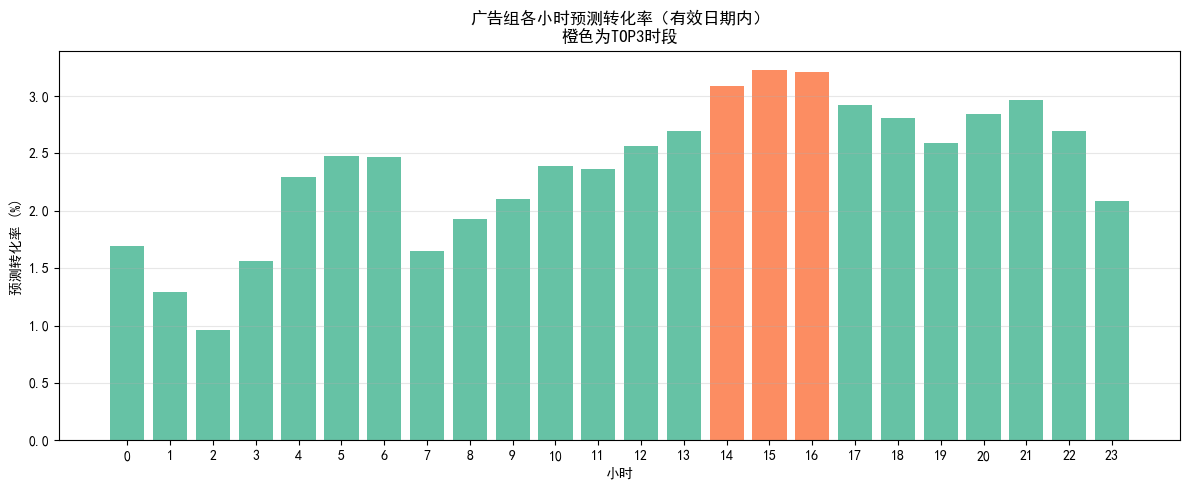


转化率最高的3个时段：
  15:00 - 预测转化率 3.2279%
  16:00 - 预测转化率 3.2130%
  14:00 - 预测转化率 3.0888%


In [20]:
# 6. 可视化
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
colors = ['#fc8d62' if hour in hourly_results.head(3)['小时'].values else '#66c2a5' 
          for hour in hourly_results['小时']]
plt.bar(hourly_results['小时'], hourly_results['预测转化率'] * 100, color=colors)
plt.xlabel('小时')
plt.ylabel('预测转化率 (%)')
plt.title('广告组各小时预测转化率（有效日期内）\n橙色为TOP3时段')
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 输出TOP3时段
print("\n转化率最高的3个时段：")
for _, row in hourly_results.head(3).iterrows():
    print(f"  {int(row['小时'])}:00 - 预测转化率 {row['预测转化率']:.4%}")